In [1]:
import keras
import tensorflow as tf
from keras import layers, models
from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Load dataset ( I made this dataset by myself btw hihi)
train_path = r'D:/Amr/Portfolio/All time project/ready to publish/DL/Project 4/dataset/train'
val_path   = r'D:/Amr/Portfolio/All time project/ready to publish/DL/Project 4/dataset/val'
test_path  = r'D:/Amr/Portfolio/All time project/ready to publish/DL/Project 4/dataset/test'

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    shuffle=True,
    pad_to_aspect_ratio=True,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    shuffle=True,
    pad_to_aspect_ratio=True,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    shuffle=False, 
    pad_to_aspect_ratio=True,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Detected {NUM_CLASSES} classes: {class_names}")


Found 64 files belonging to 3 classes.
Found 14 files belonging to 3 classes.
Found 14 files belonging to 3 classes.
Detected 3 classes: ['fish', 'plant', 'stone']


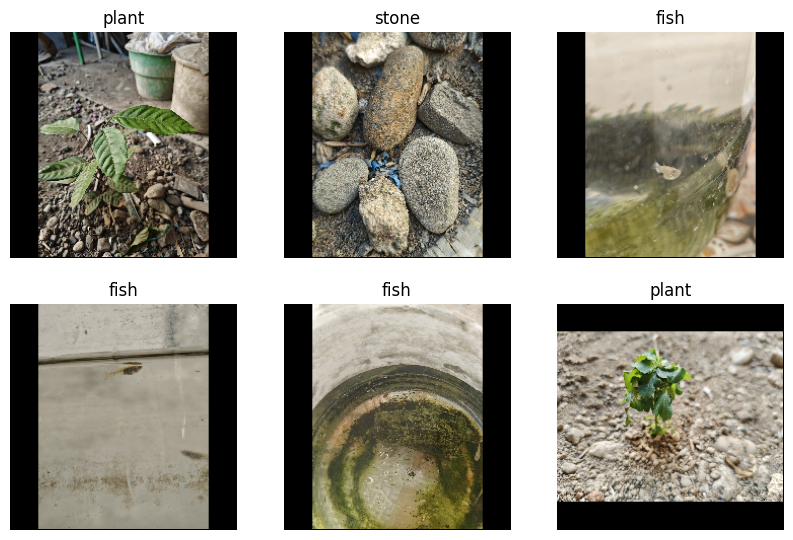

In [2]:
# Visualize
images, labels = next(iter(train_ds))
plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [3]:
# Autotune and prefetch

# To avoid bottleneck I/O when CPU read picture and GPU doing training
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

In [4]:
# Build Model (1. Extraction Feature)

# Load Pre-trained ResNet50 without classification head
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze All Layers
base_model.trainable = False

# Build Architecture
inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Preprocessing Specific for ResNet (change format RGB to BGR & zero-centering)
x = preprocess_input(inputs)

# Input to base model 
x = base_model(x, training=False)

# Classification Head Kustom
x = layers.GlobalAveragePooling2D()(x)      # to decrease feature map
x = layers.BatchNormalization()(x)          # re-scale result from GAP
x = layers.Dropout(0.3)(x)                  # to avoid overfitting, drop several layers

# Using Softmax Because Multiple Class
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
loss_fn = 'sparse_categorical_crossentropy'

model = models.Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3)         │      6,147 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,602,051 (90.03 MB)

 Trainable params: 10,243 (40.01 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [5]:
# Warm-up Classification Head
EPOCHS_WARMUP = 10

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=3, 
        restore_best_weights=True
    )
]

print("\nTraining Classification Head")
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_WARMUP,
    callbacks=callbacks
)



Training Classification Head
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3906 - loss: 1.3835 - val_accuracy: 0.3571 - val_loss: 1.9264
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step - accuracy: 0.7344 - loss: 0.5693 - val_accuracy: 0.3571 - val_loss: 1.2182
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step - accuracy: 0.8906 - loss: 0.3008 - val_accuracy: 0.7143 - val_loss: 0.7150
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step - accuracy: 0.9844 - loss: 0.1044 - val_accuracy: 0.8571 - val_loss: 0.4037
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step - accuracy: 0.9844 - loss: 0.0736 - val_accuracy: 1.0000 - val_loss: 0.2341
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step - accuracy: 1.0000 - loss: 0.0370 - val_accuracy: 1.0000 - val_loss: 0.1489
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step - accuracy: 1.0000 - loss: 0.0184 - val_accuracy: 1.0000 - val_loss: 0.1061
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step - accuracy: 1.0000 - loss: 0.0093 - val_a


Fine-Tuning Top Layers
Epoch 11/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 1.0000 - loss: 0.0152 - val_accuracy: 1.0000 - val_loss: 0.0517
Epoch 12/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 0.0450
Epoch 13/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0401
Epoch 14/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step - accuracy: 0.9844 - loss: 0.0434 - val_accuracy: 1.0000 - val_loss: 0.0363
Epoch 15/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0332
Epoch 16/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0306
Epoch 17/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0285
Epoch 18/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step - accuracy: 1.0000 - loss: 0.0012 - val

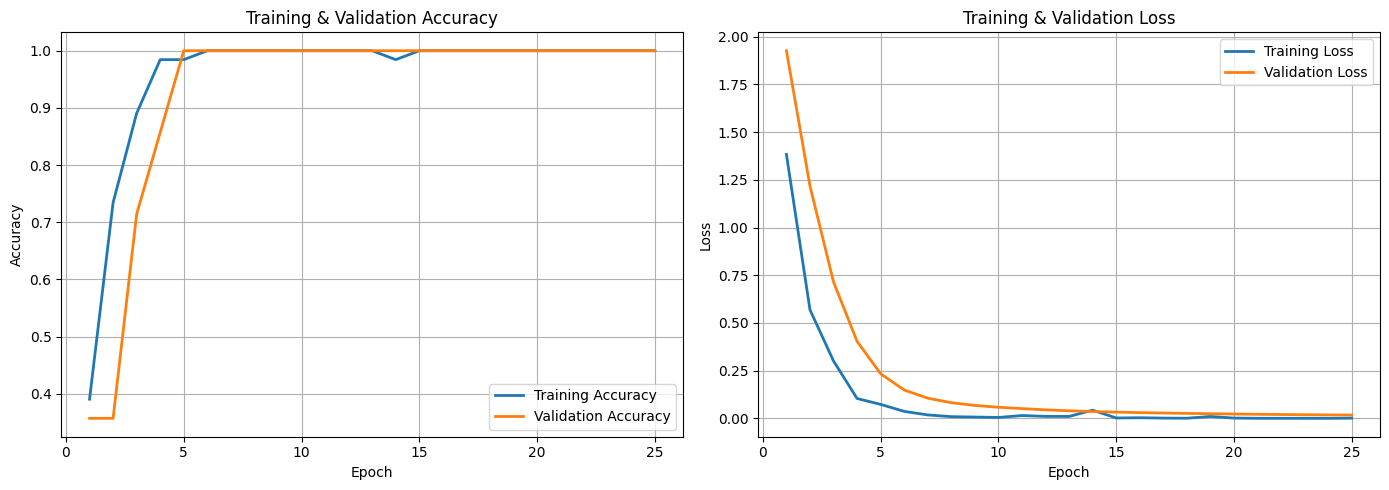

In [6]:
# Fine Tuning (Unfreeze Top Layers)

# Unfreeze base model
base_model.trainable = True

# Freeze Bottom layers, Open Top 30
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile model With Low Learning Rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

# Continue Training (Fine-Tuning)
EPOCHS_FINETUNE = 15
TOTAL_EPOCHS = len(history_warmup.history['loss']) + EPOCHS_FINETUNE

print("\nFine-Tuning Top Layers")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_warmup.epoch[-1] + 1,
    callbacks=callbacks
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Visualize Loss and Accuracy

# Combine history warmup and finetuning
acc = history_warmup.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_warmup.history['val_accuracy'] + history_finetune.history['val_accuracy']

loss = history_warmup.history['loss'] + history_finetune.history['loss']
val_loss = history_warmup.history['val_loss'] + history_finetune.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.grid(True)
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

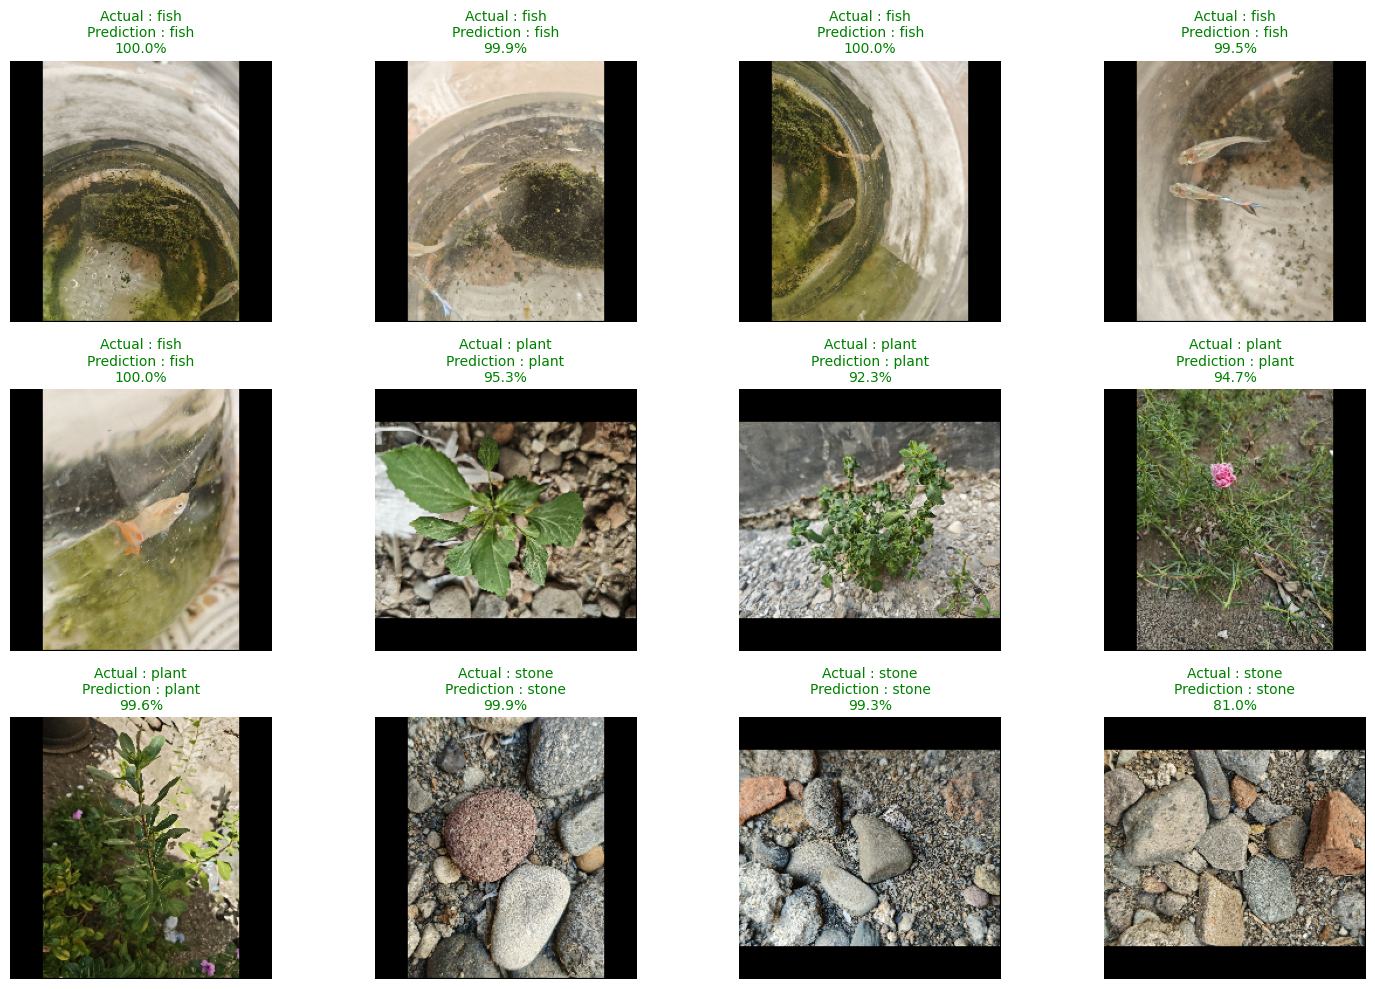

In [7]:
# Visualize Prediction Result

import numpy as np

# Take 1 batch from test dataset
images, labels = next(iter(test_ds))

# Prediction
predictions = model.predict(images, verbose=0)

# Convert Prediction Result
pred_labels = np.argmax(predictions, axis=1)
confidences = np.max(predictions, axis=1)

num_images = 12

plt.figure(figsize=(15,10))

for i in range(num_images):

    plt.subplot(3,4,i+1)

    image = images[i].numpy().astype("uint8")

    plt.imshow(image)

    true_label = class_names[int(labels[i])]
    pred_label = class_names[int(pred_labels[i])]
    confidence = confidences[i]*100

    color = "green" if true_label == pred_label else "red"

    plt.title(
        f"Actual : {true_label}\n"
        f"Prediction : {pred_label}\n"
        f"{confidence:.1f}%",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()